# Sesión 3 — Tuberías de aprendizaje automático (Parte I)
### Definición de problemas · Ingestión de datos · Preparación de datos
**Inteligencia Artificial (FP13)**

---

En esta práctica, trabajamos las **primeras tres etapas** del *machine learning pipeline* usando un
dataset real de la industria automotriz: registros históricos de **powertrain y eficiencia de
combustible** (1970–1982, dataset *Auto MPG* de UCI / Kaggle).

| Etapa del pipeline | Tema del temario | Estado |
|---|---|---|
| 1. Definición del problema | **3.1** | ✅ Esta práctica |
| 2. Ingestión de datos | **3.2** | ✅ Esta práctica |
| 3. Preparación de datos | **3.3** | ✅ Esta práctica |
| 4. Segregación de datos | 3.4 | Siguiente práctica |
| 5. Modelo de entrenamiento | 3.5 | Siguiente práctica |

<br>

**Nota de alcance:** la *normalización* y la *codificación one-hot* se presentan de forma
**superficial** (vista previa). Se profundizan en la **Unidad 4** (Selección e ingeniería de funciones).


> ### Cómo trabajar este notebook
> Este cuaderno está **vacío a propósito**. Cada celda de código trae un marcador
> `# >>> BLOQUE n <<<`. Localiza en el cuadernillo el bloque con el **mismo número**,
> cópialo, pégalo **debajo del marcador** y ejecuta la celda con `Shift + Enter`.
>
> El notebook debe guardarse en la misma carpeta que contiene el directorio `Dataset_1/`
> con los cuatro archivos de datos.


## 0 · Preparación del entorno
Importamos las librerías y fijamos opciones de visualización.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




## 3.1 · Definición del problema
> *"Bob dedicó años a planear, ejecutar y optimizar cómo conquistar una colina.
> Por desgracia, resultó ser la colina equivocada."*

Antes de tocar una sola línea de datos hay que **enmarcar la pregunta correcta**. Una mala
definición cuesta órdenes de magnitud más adelante en el pipeline.

**Contexto de negocio (automotriz).** Un fabricante quiere entender qué características del
*powertrain* determinan la **eficiencia de combustible** de un vehículo, para orientar el diseño
de futuras plataformas.

| Iteración | Pregunta | Problema |
|---|---|---|
| v1 | ¿El auto es eficiente, sí o no? | Binario pobre; pierde magnitud |
| v2 | ¿Cuántas millas por galón rinde? | Mejor, pero unidad imperial |
| v3 | ¿Cuál es el **consumo (L/100 km)** dado el powertrain? | Métrica útil para ingeniería |
| v4 | ¿Consumo **sin usar variables no permitidas** (p. ej. el nombre comercial)? | Evita fugas y sesgos |

**Problema definido para esta sesión:** *predecir el consumo (L/100 km) de un vehículo a
partir de sus características técnicas (cilindros, cilindrada, potencia, peso, etc.).*
Esta definición determina **qué datos** ingerimos y **cómo** los preparamos.


## 3.2 · Ingestión de datos
Los datos casi nunca llegan en un solo archivo ni en un solo formato. En este caso el proveedor
entrega **4 fuentes** en **4 formatos** distintos:

| Fuente | Archivo | Formato | Detalle a cuidar |
|---|---|---|---|
| Planta Norteamérica | `flota_norteamerica.csv` | CSV | Separador por comas |
| Planta Europa | `flota_europa.xlsx` | Excel | Varias hojas (`sheet_name`) |
| Planta Asia | `flota_asia.txt` | TXT delimitado por `~` | Valores faltantes |
| Data lake | `flota_datalake.parquet` | Parquet | Formato columnar binario |


### 3.2.1 · CSV — `pd.read_csv`

In [4]:
df_csv = pd.read_csv('Dataset_1/flota_norteamerica.csv')
print(f'CSV  -> {df_csv.shape}')
df_csv.head(3)




CSV  -> (249, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite


### 3.2.2 · Excel — `pd.read_excel`
Un `.xlsx` puede tener varias hojas. Elegimos la hoja de datos con `sheet_name`.
La segunda hoja es un **diccionario de datos** (muy útil para documentar el proyecto).

In [5]:
# Ver qué hojas trae el archivo
print('Hojas:', pd.ExcelFile('Dataset_1/flota_europa.xlsx').sheet_names)
 
df_xls = pd.read_excel('Dataset_1/flota_europa.xlsx', sheet_name='registros')
print(f'Excel -> {df_csv.shape}')
df_xls.head(3)


Hojas: ['registros', 'diccionario']
Excel -> (249, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,26.0,4,97,46.0,1835,20.5,70,2,volkswagen 1131 deluxe sedan
1,25.0,4,110,87.0,2672,17.5,70,2,peugeot 504
2,24.0,4,107,90.0,2430,14.5,70,2,audi 100 ls


In [6]:
# La hoja 'diccionario' documenta cada columna
pd.read_excel('Dataset_1/flota_europa.xlsx', sheet_name='diccionario')



,columna,descripcion
0,mpg,Millas por galon (eficiencia)
1,cylinders,Numero de cilindros
2,displacement,Cilindrada (pulgadas cubicas)
3,horsepower,Potencia (hp)
4,weight,Peso del vehiculo (libras)
5,acceleration,Tiempo 0-60 mph (segundos)
6,model_year,Anio de modelo (19xx)
7,origin,Region: 1=EUA 2=Europa 3=Japon
8,name,Marca y modelo (texto libre)


### 3.2.3 · TXT delimitado por `~` — `pd.read_csv` con `sep`
`read_csv` sirve para **cualquier** texto delimitado, no solo comas. Aquí el separador es `~`.

In [7]:
# Importando archivo
df_txt = pd.read_csv('Dataset_1/flota_asia.txt', sep='~') #, na_values='?'  >>> Instrucción por si los valores Nulos vinieran enmascarádos con un signo ?
 
print(f'TXT -> {df_txt.shape}')
df_txt.head(3)



TXT -> (79, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,24.0,4,113.0,95.0,2372,15.0,70,3,toyota corona mark ii
1,27.0,4,97.0,88.0,2130,14.5,70,3,datsun pl510
2,27.0,4,97.0,88.0,2130,14.5,71,3,datsun pl510


### 3.2.4 · Parquet — `pd.read_parquet`
Parquet es un formato **columnar y comprimido**, el estándar en *data lakes* (Spark, Hadoop,
S3). Conserva los tipos de dato y ocupa mucho menos espacio que un CSV.

In [8]:
df_pq = pd.read_parquet('Dataset_1/flota_datalake.parquet')
 
print(f'Parquet -> {df_pq.shape}')
df_pq.head(3)


Parquet -> (12, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,31.0,4,79.0,67.0,2000,16.0,74,2,fiat x1.9
1,26.0,4,98.0,90.0,2265,15.5,73,2,fiat 124 sport coupe
2,18.2,8,318.0,135.0,3830,15.2,79,1,dodge st. regis


### 3.2.5 · Consolidación de fuentes
Como las cuatro fuentes comparten esquema, las **apilamos** con `pd.concat`. En un proyecto real
podríamos necesitar `merge`/`join` si vinieran con llaves distintas.

> Otros formatos frecuentes que se leen igual de fácil: `pd.read_json`, `pd.read_sql`,
> `pd.read_html`.

In [9]:
df = pd.concat([df_csv, df_xls, df_txt, df_pq], ignore_index=True)
 
print(f'Dataset consolidado -> {df.shape}')
df.sample(4, random_state=1)



Dataset consolidado -> (410, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
284,27.0,4,101.0,83.0,2202,15.3,76,2,renault 12tl
29,14.0,8,350.0,165.0,4209,12.0,71,1,chevrolet impala
186,21.5,6,231.0,115.0,3245,15.4,79,1,pontiac lemans v6
291,29.0,4,97.0,78.0,1940,14.5,77,2,volkswagen rabbit custom


## 3.3 · Preparación de datos
Es la etapa que **más tiempo consume** en ciencia de datos. Recorremos las siete técnicas del
libro, en el orden del temario.

### 3.3.0 · Radiografía inicial
Antes de limpiar, hay que *entender* el estado de los datos.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           410 non-null    float64
 1   cylinders     410 non-null    int64  
 2   displacement  410 non-null    float64
 3   horsepower    404 non-null    float64
 4   weight        410 non-null    int64  
 5   acceleration  410 non-null    float64
 6   model_year    410 non-null    int64  
 7   origin        410 non-null    int64  
 8   name          410 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 29.0+ KB


In [11]:
# Faltantes y duplicados
print('Filas duplicadas:', df.duplicated().sum())
print('\nFaltantes por columna:')
print(df.isnull().sum())



Filas duplicadas: 12

Faltantes por columna:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,410.0,23.504634,7.880535,9.0,17.00,23.0,29.000,46.6
cylinders,410.0,5.465854,1.708616,3.0,4.00,4.0,8.000,8.0
displacement,410.0,194.350000,105.713342,68.0,101.75,148.5,293.250,455.0
horsepower,404.0,105.042079,39.253717,46.0,75.00,93.5,130.000,230.0
weight,410.0,2980.065854,857.932785,1613.0,2220.75,2811.0,3618.250,5140.0
acceleration,410.0,15.539268,2.771024,8.0,13.80,15.5,17.075,24.8
model_year,410.0,76.012195,3.710469,70.0,73.00,76.0,79.000,82.0
origin,410.0,1.580488,0.803178,1.0,1.00,1.0,2.000,3.0


### (1) Imputar valores faltantes
`horsepower` tiene faltantes. El libro describe **seis estrategias**:

1. **No hacer nada** (algoritmos como XGBoost los toleran).
2. **Imputar con la mediana** — rápido y robusto a valores extremos ✅ *(la usaremos)*.
3. **Imputar con la media** — sensible a outliers.
4. **Valor más frecuente / constante** — sirve para variables no numéricas.
5. **Imputación por modelo** (KNN, regresión) — más precisa, más costosa.
6. **Eliminar las filas/columnas** — solo si son muy pocas.

Usamos la **mediana** porque la potencia tiene distribución sesgada y algunos valores altos.

In [13]:
nulos_hp = df['horsepower'].isna().sum()
print(f'Faltantes en horsepower (antes): {nulos_hp}')
 
mediana_hp = df['horsepower'].median()
df['horsepower'] = df['horsepower'].fillna(mediana_hp)
 
print(f'Mediana usada: {mediana_hp:.1f} hp')
 
nulos_hp = df['horsepower'].isna().sum()
print(f'Faltantes en horsepower (después): {nulos_hp}')


Faltantes en horsepower (antes): 6
Mediana usada: 93.5 hp
Faltantes en horsepower (después): 0


### (2) Eliminar registros duplicados
El *data lake* reingirió registros que ya existían en otras fuentes. `drop_duplicates` elimina
filas idénticas.

> En la práctica, los duplicados "difusos" (mismo auto con pequeñas diferencias de texto) no se
> detectan con igualdad exacta; ahí se usa **fuzzy matching**.

In [14]:
print('Filas antes:', len(df), '| duplicadas:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('Filas después:', len(df))



Filas antes: 410 | duplicadas: 12
Filas después: 398


### (3) Normalización y codificación one-hot — *vista previa*
> ⚠️ **Superficial.** Se profundiza en la **Unidad 4**. Aquí solo mostramos qué hacen.

**Normalización / escalado:** lleva variables de distintas magnitudes a una escala común. Muchos
algoritmos que usan distancias (KNN, SVM) lo necesitan.

In [16]:
# Nota para instalar la libreria: pip install scikit-learn (en terminal)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
 
muestra = df[['weight', 'horsepower']].copy()
 
# Estandarización (Z-score): media 0, desviación estándar 1
z = StandardScaler().fit_transform(muestra)
# Min-Max: lleva todo al rango [0, 1]
mm = MinMaxScaler().fit_transform(muestra)
 
# Usando f-strings para una sintaxis más limpia y directa
print(f"Original    -> weight medio: {muestra['weight'].mean():.0f}")
print(f"Z-score     -> media ≈ {z.mean():.2f}, std ≈ {z.std():.2f}")
print(f"Min-Max     -> min = {mm.min():.2f}, max = {mm.max():.2f}")


Original    -> weight medio: 2970
Z-score     -> media ≈ -0.00, std ≈ 1.00
Min-Max     -> min = 0.00, max = 1.00


**Codificación one-hot:** convierte una variable categórica en columnas binarias (0/1), porque
los modelos no operan con texto. Ejemplo con la región de origen.

In [17]:
# origin: 1=EUA, 2=Europa, 3=Japón  (lo mapeamos a texto solo para el ejemplo)
ejemplo_region = df['origin'].map({1: 'EUA', 2: 'Europa', 3: 'Japon'})
pd.get_dummies(ejemplo_region, prefix='reg', drop_first=True).head(4)



,reg_Europa,reg_Japon
0,False,False
1,False,False
2,False,False
3,False,False


### (4) Otro tipo de limpieza y mapeos
Tres tareas típicas:
1. **Renombrar columnas** a español (legibilidad del proyecto).
2. **Mapear códigos** de `origin` (1/2/3) a etiquetas de región.
3. **Convertir unidades imperiales a métricas** — clave para ingeniería automotriz en México
   (litros, kilogramos, L/100 km).

In [18]:
# 1) Renombrar columnas
df = df.rename(columns={
    'mpg': 'millas_galon', 'cylinders': 'cilindros', 'displacement': 'cilindrada_pulg3',
    'horsepower': 'potencia_hp', 'weight': 'peso_lb', 'acceleration': 'aceleracion_s',
    'model_year': 'año_modelo', 'name': 'nombre'
})
 
# 2) Mapear código de origen -> región
df['region'] = df['origin'].map({1: 'EUA', 2: 'Europa', 3: 'Japon'})
 
# 3) Conversión a sistema métrico
df['cilindrada_L'] = (df['cilindrada_pulg3'] * 0.0163871).round(2)   # pulg³ -> L
df['peso_kg']      = (df['peso_lb'] * 0.453592).round(0)             # lb   -> kg
df['consumo_L_100km'] = (235.215 / df['millas_galon']).round(2)      # mpg  -> L/100km
 
df[['nombre', 'region', 'cilindrada_L', 'peso_kg', 'consumo_L_100km']].head(4)


,nombre,region,cilindrada_L,peso_kg,consumo_L_100km
0,chevrolet chevelle malibu,EUA,5.03,1589.0,13.07
1,buick skylark 320,EUA,5.74,1675.0,15.68
2,plymouth satellite,EUA,5.21,1559.0,13.07
3,amc rebel sst,EUA,4.98,1557.0,14.70


### (5) Extracción de características
La columna `nombre` es **texto libre** que mezcla marca y modelo. Extraemos la **marca** (primer
token) y, de paso, corregimos inconsistencias reales del dataset (errores de captura y alias):
`chevy`/`chevroelt` → `chevrolet`, `maxda` → `mazda`, `toyouta` → `toyota`,
`vw`/`vokswagen` → `volkswagen`.

In [19]:
print('Marcas distintas antes de normalizar:', df['nombre'].nunique())
 
# Diccionario de normalización de marcas (mapeo basado en reglas)
correcciones = {
    'chevroelt': 'chevrolet', 'chevy': 'chevrolet', 'maxda': 'mazda',
    'toyouta': 'toyota', 'vw': 'volkswagen', 'vokswagen': 'volkswagen',
    'mercedes-benz': 'mercedes'
}
df['marca'] = df['nombre'].str.split().str[0].replace(correcciones)
 
print('Marcas distintas tras normalizar:', df['marca'].nunique())
df['marca'].value_counts().head(8)


Marcas distintas antes de normalizar: 305
Marcas distintas tras normalizar: 30


marca
ford          51
chevrolet     47
plymouth      31
amc           28
dodge         28
toyota        26
datsun        23
volkswagen    22
Name: count, dtype: int64

In [ ]:
# Explicación del código de normalización de marcas

# ==============================================================================
# EXPLICACIÓN PASO A PASO:
# df['marca'] = df['nombre'].str.split().str[0].replace(correcciones)
# ==============================================================================
#
# 1. df['nombre']
#    Toma la columna original que contiene el nombre completo del auto.
#    Ejemplo: "chevroelt malibu lz"
#
# 2. .str.split()
#    Trata el texto como cadena (str) y lo divide por los espacios en blanco, 
#    creando una lista de palabras por cada fila.
#    Ejemplo: ["chevroelt", "malibu", "lz"]
#
# 3. .str[0]
#    Accede a la lista recién creada y extrae únicamente el primer elemento 
#    (el índice 0), asumiendo que la primera palabra siempre es la marca.
#    Ejemplo: "chevroelt"
#
# 4. .replace(correcciones)
#    Toma esa primera palabra y la busca en el diccionario de correcciones.
#    Si la encuentra (ej. "chevroelt"), la cambia por su valor ("chevrolet").
#    Si NO la encuentra (ej. "ford"), la deja intacta.
#
# 5. df['marca'] = ...
#    Asigna todo este resultado final a una nueva columna llamada 'marca'.
# ==============================================================================

### (6) Eliminar variables correlacionadas
Dos variables muy correlacionadas aportan **información redundante** (multicolinealidad):
inflan la complejidad, desestabilizan algunos modelos y dificultan la interpretación.

In [20]:
num = ['millas_galon', 'cilindros', 'cilindrada_L', 'potencia_hp',
       'peso_kg', 'aceleracion_s', 'consumo_L_100km']
corr = df[num].corr()
corr.round(2)


,millas_galon,cilindros,cilindrada_L,potencia_hp,peso_kg,aceleracion_s,consumo_L_100km
millas_galon,1.00,-0.78,-0.80,-0.77,-0.83,0.42,-0.94
cilindros,-0.78,1.00,0.95,0.84,0.90,-0.51,0.84
cilindrada_L,-0.80,0.95,1.00,0.90,0.93,-0.54,0.87
potencia_hp,-0.77,0.84,0.90,1.00,0.86,-0.69,0.85
peso_kg,-0.83,0.90,0.93,0.86,1.00,-0.42,0.89
aceleracion_s,0.42,-0.51,-0.54,-0.69,-0.42,1.00,-0.46
consumo_L_100km,-0.94,0.84,0.87,0.85,0.89,-0.46,1.00


**Mapa de calor de correlaciones** — el recurso visual clave de esta etapa.

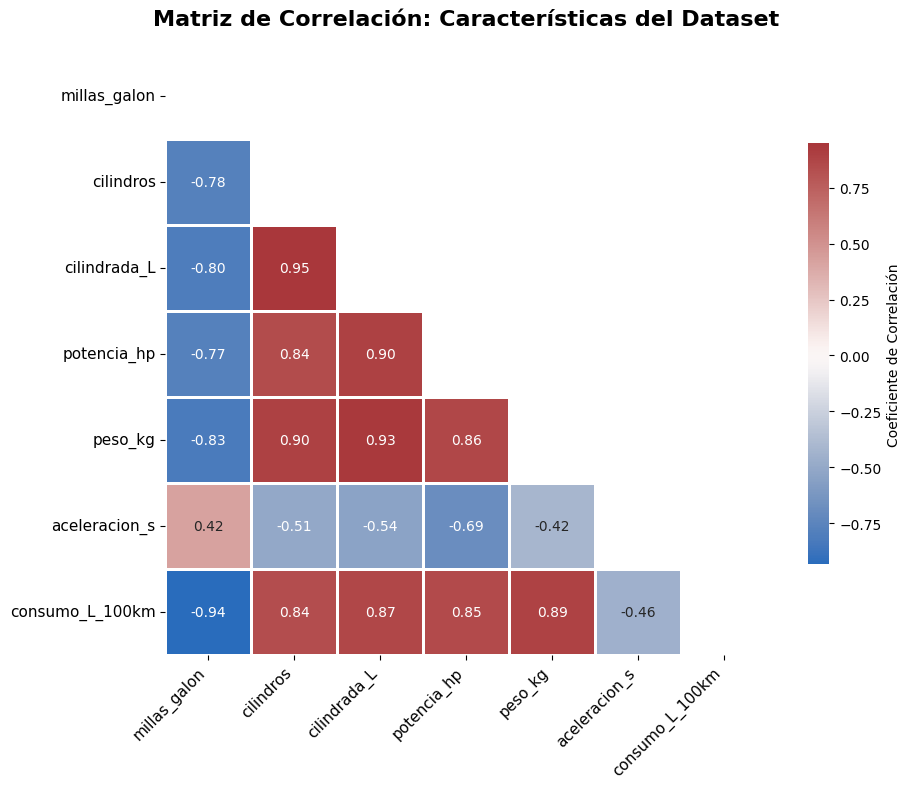

In [21]:
# 1. Crear una máscara para ocultar el triángulo superior (información redundante)
mask = np.triu(np.ones_like(corr, dtype=bool))
 
# 2. Ajustar el tamaño para que respire mejor
plt.figure(figsize=(10, 8))
 
# 3. Crear una paleta de colores divergente más suave y elegante
cmap = sns.diverging_palette(230, 20, as_cmap=True)
 
# 4. Generar el heatmap con los nuevos ajustes
sns.heatmap(corr, 
            mask=mask, 
            annot=True, 
            fmt='.2f', 
            cmap=sns.color_palette("vlag", as_cmap=True),
            center=0,
            square=True, 
            linewidths=1,           # Líneas de separación un poco más gruesas
            linecolor='white',      # Color de separación en blanco para un look limpio
            cbar_kws={'shrink': .7, 'label': 'Coeficiente de Correlación'}, # Etiqueta en la barra derecha
            annot_kws={'size': 10, 'weight': '500'}) # Números más legibles
 
# 5. Título de la gráfica
plt.title('Matriz de Correlación: Características del Dataset', 
          fontsize=16, fontweight='bold', pad=20)
 
# Rotar etiquetas para que no se encimen
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
 
plt.tight_layout()
plt.show()


**Matriz de dispersión** — muestra las relaciones par a par de forma cruda.

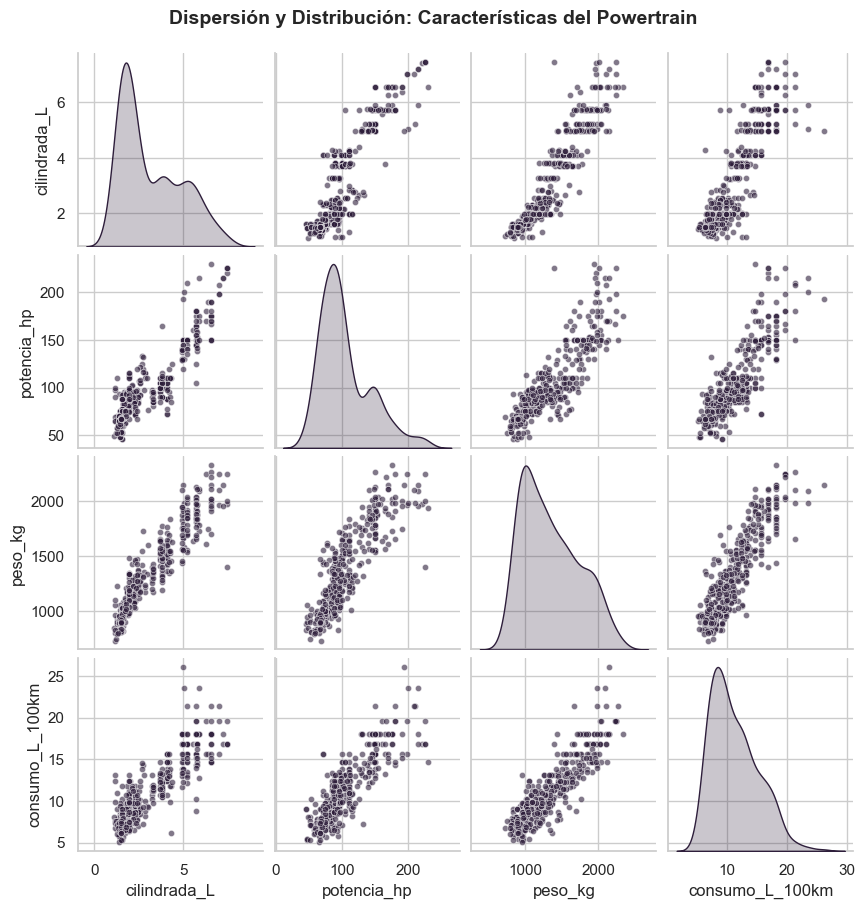

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
 
# 1. Configurando tema de colores
sns.set_theme(style="whitegrid", palette="mako") 
 
# 2. Generando el pairplot
g = sns.pairplot(
    df[['cilindrada_L', 'potencia_hp', 'peso_kg', 'consumo_L_100km']],
    height=2.2,
    diag_kind='kde',        # Mostrando curvas de densidad en lugar de histogramas rectos
    plot_kws={
        'alpha': 0.6,       # Transparencia para ver superposición de puntos
        's': 20,            # Tamaño del punto
        'edgecolor': 'w',   # Borde blanco fino en los puntos para que resalten
        'linewidth': 0.5
    }
)
 
# 3. Título de la gráfica
g.fig.suptitle('Dispersión y Distribución: Características del Powertrain', 
               y=1.03, fontsize=14, fontweight='bold')
 
plt.show()


**Detección automática de pares redundantes** (`|r| > 0.9`) y decisión de qué conservar.

In [23]:
umbral = 0.9
pares = [(a, b, round(corr.loc[a, b], 2))
         for i, a in enumerate(num) for b in num[i+1:]
         if abs(corr.loc[a, b]) > umbral]
print('Pares altamente correlacionados (|r| > 0.9):')
for a, b, r in pares:
    print(f'  {a:16s} <-> {b:16s}  r = {r}')


Pares altamente correlacionados (|r| > 0.9):
  millas_galon     <-> consumo_L_100km   r = -0.94
  cilindros        <-> cilindrada_L      r = 0.95
  cilindrada_L     <-> peso_kg           r = 0.93


**Criterio de la clase:** `cilindros`, `cilindrada_L` y `peso_kg` describen "el tamaño del
motor/auto". Conservamos **`peso_kg`** (la más informativa para consumo) y descartamos
`cilindrada_L` y `cilindros` como candidatas redundantes.

In [24]:
redundantes = ['cilindrada_L', 'cilindros']
df_reducido = df.drop(columns=redundantes)
print('Columnas eliminadas por redundancia:', redundantes)
print('Shape tras reducción:', df_reducido.shape)


Columnas eliminadas por redundancia: ['cilindrada_L', 'cilindros']
Shape tras reducción: (398, 12)


### (7) Ingeniería de características
Creamos variables **nuevas y más predictivas** combinando las existentes. Todas con sentido
físico/automotriz:

- `relacion_pot_peso` = potencia / peso → **relación potencia-peso** (desempeño).
- `cilindrada_por_cil` = cilindrada / cilindros → **cilindrada unitaria**.
- `antiguedad` = 82 − año de modelo → posición temporal.


In [25]:
df['relacion_pot_peso']  = (df['potencia_hp'] / df['peso_kg']).round(4)
df['cilindrada_por_cil'] = (df['cilindrada_L'] / df['cilindros']).round(3)
df['antiguedad'] = 82 - df['año_modelo']
 
df[['nombre', 'potencia_hp', 'peso_kg', 'relacion_pot_peso',
    'cilindrada_por_cil', 'antiguedad']].head(4)


,nombre,potencia_hp,peso_kg,relacion_pot_peso,cilindrada_por_cil,antiguedad
0,chevrolet chevelle malibu,130.0,1589.0,0.0818,0.629,12
1,buick skylark 320,165.0,1675.0,0.0985,0.718,12
2,plymouth satellite,150.0,1559.0,0.0962,0.651,12
3,amc rebel sst,150.0,1557.0,0.0963,0.622,12


## Cierre — dataset listo para modelar
Partimos de 4 archivos crudos en 4 formatos y obtuvimos un dataset **consolidado, limpio y
enriquecido**.


In [26]:
# Eliminando variables originales en unidades imperiales
df = df.drop(columns = ['millas_galon', 'cilindrada_pulg3', 'peso_lb', 'aceleracion_s', 'año_modelo', 'origin', 'nombre'])


In [27]:
print('Dataset final:', df.shape)
print('Columnas:', list(df.columns))
df.head()


Dataset final: (398, 10)
Columnas: ['cilindros', 'potencia_hp', 'region', 'cilindrada_L', 'peso_kg', 'consumo_L_100km', 'marca', 'relacion_pot_peso', 'cilindrada_por_cil', 'antiguedad']


,cilindros,potencia_hp,region,cilindrada_L,peso_kg,consumo_L_100km,marca,relacion_pot_peso,cilindrada_por_cil,antiguedad
0,8,130.0,EUA,5.03,1589.0,13.07,chevrolet,0.0818,0.629,12
1,8,165.0,EUA,5.74,1675.0,15.68,buick,0.0985,0.718,12
2,8,150.0,EUA,5.21,1559.0,13.07,plymouth,0.0962,0.651,12
3,8,150.0,EUA,4.98,1557.0,14.70,amc,0.0963,0.622,12
4,8,140.0,EUA,4.95,1564.0,13.84,ford,0.0895,0.619,12
